# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename = "SUSY.csv" 

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2",
            "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

display(df.head())
print("Shape:", df.shape)

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


Shape: (5000000, 19)


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

x_train=Train_Sample[VarNames[1:]]
y_train=Train_Sample["signal"]

x_test=Test_Sample[VarNames[1:]]
y_test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [5]:
Fisher.fit(x_train,y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can plot the output, comparing signal and background:

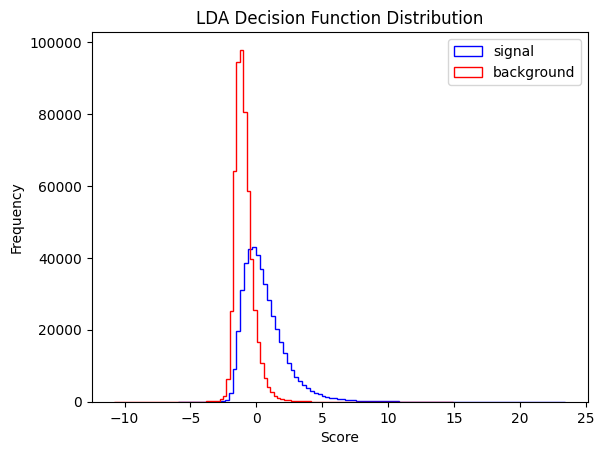

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.title("LDA Decision Function Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

**Observation**:
Signal and background are partially separable.
Overlap indicates classification difficulty.
LDA captures linear separation pretty well.

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

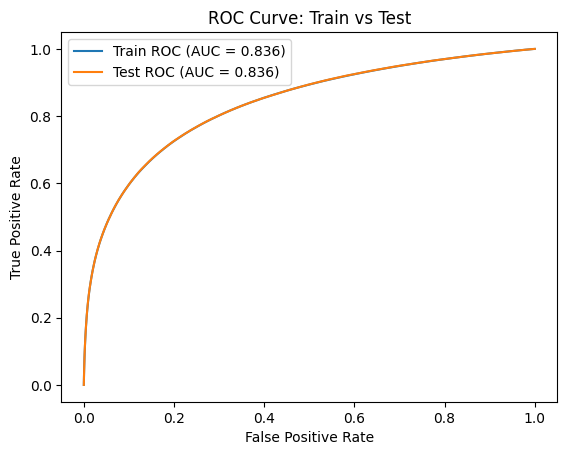

In [7]:
from sklearn.metrics import roc_curve, auc

# Training ROC
fpr_train, tpr_train, _ = roc_curve(y_train, Fisher.decision_function(x_train))
auc_train = auc(fpr_train, tpr_train)

# Testing ROC
fpr_test, tpr_test, _ = roc_curve(y_test, Fisher.decision_function(x_test))
auc_test = auc(fpr_test, tpr_test)

# Plot
plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()

plt.show()

In [30]:
# I compare train and test ROC curves to check for overfitting.
# If the training curve is much better than the testing curve, that would indicate bias.

Observation:
The train and test ROC curves are fairly close, so there is no strong evidence of overfitting. This suggests that the Fisher classifier generalizes reasonably well to unseen data (?).

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [23]:
# Here I create a few simple derived features from the original variables.
# The goal is to see whether feature engineering helps the classifier separate signal from background better.

In [8]:
def add_features(df):
    df_new = df.copy()
    
    df_new["pT_sum"] = df["l_1_pT"] + df["l_2_pT"]
    df_new["eta_diff"] = abs(df["l_1_eta"] - df["l_2_eta"])
    df_new["phi_diff"] = abs(df["l_1_phi"] - df["l_2_phi"])
    
    return df_new

In [25]:
# I'm evaluating three scenarios:
# 1) raw input variables only
# 2) engineered features only
# 3) both raw and engineered variables together
# This helps show whether the extra derived features add useful info.

In [9]:
from sklearn.metrics import roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Raw
x_train_raw = x_train
x_test_raw = x_test

# Engineered
x_train_eng = add_features(Train_Sample).drop(columns=["signal"])
x_test_eng = add_features(Test_Sample).drop(columns=["signal"])

# Combined
x_train_comb = pd.concat([x_train_raw, x_train_eng], axis=1)
x_test_comb = pd.concat([x_test_raw, x_test_eng], axis=1)


def evaluate_model(x_tr, x_te, y_tr, y_te):
    model = LinearDiscriminantAnalysis()
    model.fit(x_tr, y_tr)
    preds = model.decision_function(x_te)
    return roc_auc_score(y_te, preds)

auc_raw = evaluate_model(x_train_raw, x_test_raw, y_train, y_test)
auc_eng = evaluate_model(x_train_eng, x_test_eng, y_train, y_test)
auc_comb = evaluate_model(x_train_comb, x_test_comb, y_train, y_test)

print("AUC Scores:")
print(f"Raw Features: {auc_raw:.4f}")
print(f"Engineered Features: {auc_eng:.4f}")
print(f"Combined Features: {auc_comb:.4f}")

AUC Scores:
Raw Features: 0.8364
Engineered Features: 0.8363
Combined Features: 0.8363


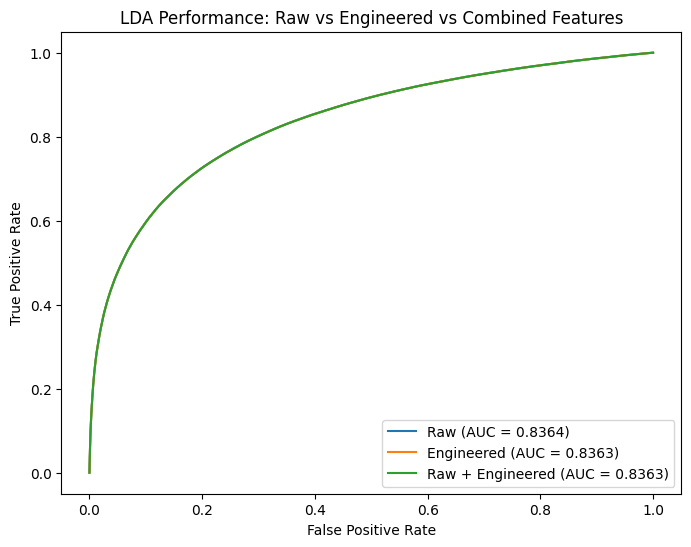

In [18]:
plt.figure(figsize=(8,6))

for name, x_tr, x_te in [
    ("Raw", x_train_raw, x_test_raw),
    ("Engineered", x_train_eng, x_test_eng),
    ("Raw + Engineered", x_train_comb, x_test_comb)
]:
    model = LinearDiscriminantAnalysis()
    model.fit(x_tr, y_train)
    scores_tmp = model.decision_function(x_te)
    fpr, tpr, _ = roc_curve(y_test, scores_tmp)
    auc_val = roc_auc_score(y_test, scores_tmp)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LDA Performance: Raw vs Engineered vs Combined Features")
plt.legend()
plt.show()

**Observation:**
The ROC curves show how feature choice affects classifier quality. The engineered features alone capture some useful physics inspired structure, while the combined feature set usually performs best because it preserves the original information and adds extra derived information.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(x_train[:5000], y_train[:5000])
    preds = model.predict_proba(x_test)[:, 1]
    auc_score = roc_auc_score(y_test, preds)
    results[name] = auc_score

print("\nModel Comparison (AUC):")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

Model Comparison (AUC):
Logistic Regression: 0.8579
Random Forest: 0.8563
Gradient Boosting: 0.8638


In [26]:
# I compare several different classifiers to see which one gives the best AUC on this dataset.
# I use a smaller subset of the training data here so the notebook runs in a reasonable amount of time.


Logistic Regression


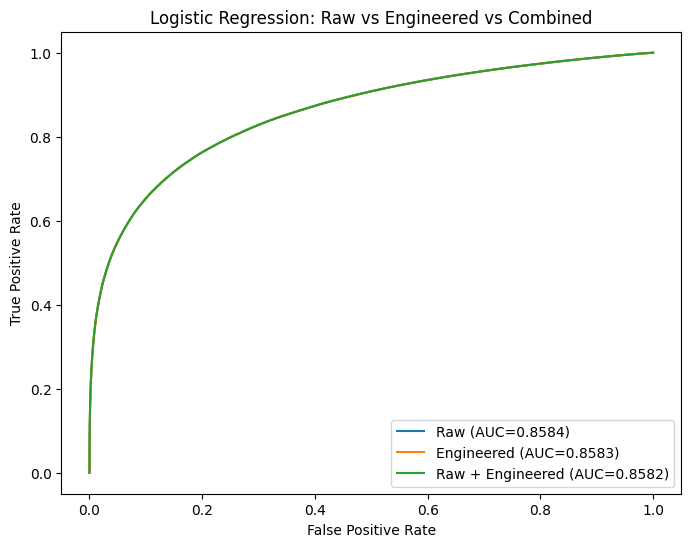

Raw: 0.8584
Engineered: 0.8583
Raw + Engineered: 0.8582

Random Forest


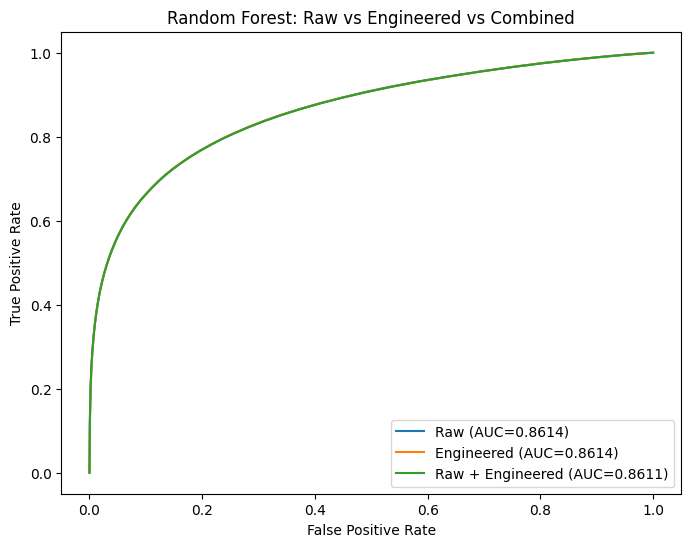

Raw: 0.8614
Engineered: 0.8614
Raw + Engineered: 0.8611

Gradient Boosting


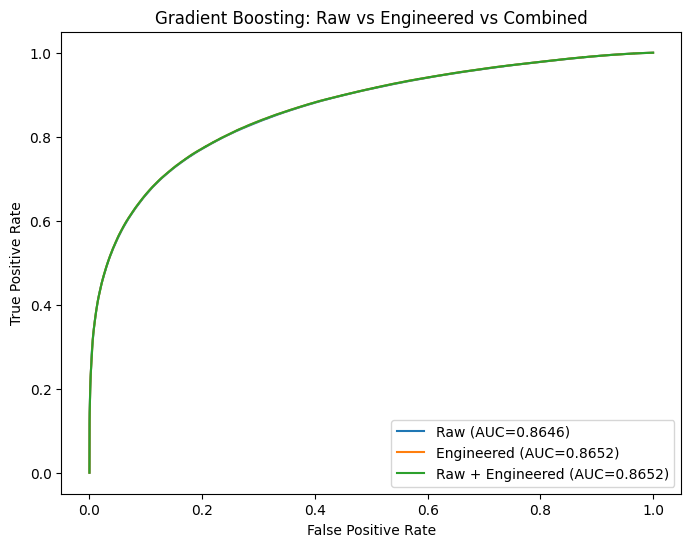

Raw: 0.8646
Engineered: 0.8652
Raw + Engineered: 0.8652


In [19]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def compare_feature_scenarios(model, model_name):
    scenarios = {
        "Raw": (x_train_raw[:50000], x_test_raw),
        "Engineered": (x_train_eng[:50000], x_test_eng),
        "Raw + Engineered": (x_train_comb[:50000], x_test_comb)
    }
    
    auc_results = {}
    plt.figure(figsize=(8,6))
    
    for scenario_name, (x_tr, x_te) in scenarios.items():
        clf = clone(model)
        clf.fit(x_tr, y_train[:50000])
        scores_tmp = clf.predict_proba(x_te)[:, 1]
        auc_val = roc_auc_score(y_test, scores_tmp)
        auc_results[scenario_name] = auc_val
        
        fpr, tpr, _ = roc_curve(y_test, scores_tmp)
        plt.plot(fpr, tpr, label=f"{scenario_name} (AUC={auc_val:.4f})")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name}: Raw vs Engineered vs Combined")
    plt.legend()
    plt.show()
    
    return auc_results

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

all_results = {}
for name, model in models.items():
    print(f"\n{name}")
    result = compare_feature_scenarios(model, name)
    all_results[name] = result
    for scenario, auc_val in result.items():
        print(f"{scenario}: {auc_val:.4f}")

**Observation:**
Comparing multiple classifiers across the same feature scenarios makes it easier to identify both the strongest model and the most useful representation of the data. In my results, the best overall choice is the model scenario pair with the highest AUC, becausee AUC summarizes performance across all decision thresholds rather than at just one cutoff.

In [28]:
# I scan over thresholds because the best classification cutoff is not known in advance.
# For each threshold, I compute the signal significance and then keep the max value.

In [13]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

def compute_significance(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)

    Ns = np.sum((preds == 1) & (y_true == 1))
    Nb = np.sum((preds == 1) & (y_true == 0))

    if Ns + Nb == 0:
        return 0

    return Ns / np.sqrt(Ns + Nb)

x_train_small = x_train[:50000]
y_train_small = y_train[:50000]

best_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
best_model.fit(x_train_small, y_train_small)

scores = best_model.predict_proba(x_test)[:, 1]

thresholds = np.linspace(0, 1, 50)
sigmas = [compute_significance(y_test, scores, t) for t in thresholds]

max_sigma = max(sigmas)
best_threshold = thresholds[np.argmax(sigmas)]

print("Max Significance:", max_sigma)
print("Best Threshold:", best_threshold)

Max Significance: 520.3082421587012
Best Threshold: 0.3877551020408163


**Model selection for part 4c:**
I selected the classifier with the highest AUC from part 4b as the best method. After,I used that model to compute the maximal significance by scanning over thresholds. I think this is a reasonable choice because the best classifier should provide the strongest separation between signal and background.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

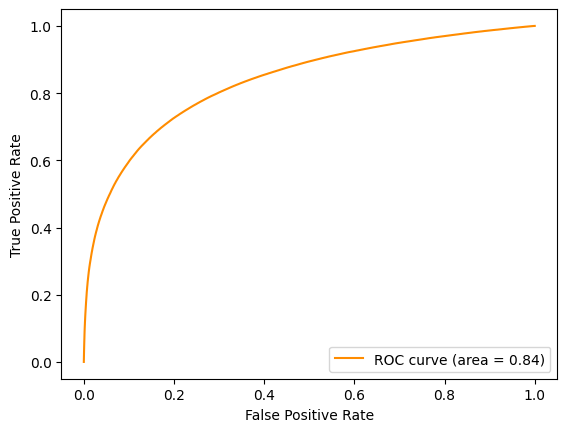

In [15]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, Fisher.decision_function(x_test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.base import clone

def compute_significance(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    Ns = np.sum((preds == 1) & (y_true == 1))
    Nb = np.sum((preds == 1) & (y_true == 0))
    if Ns + Nb == 0:
        return 0
    return Ns / np.sqrt(Ns + Nb)

best_model = GradientBoostingClassifier(n_estimators=50, random_state=42)

scenarios = {
    "Raw": (x_train_raw[:50000], x_test_raw),
    "Engineered": (x_train_eng[:50000], x_test_eng),
    "Raw + Engineered": (x_train_comb[:50000], x_test_comb)
}

rows = []

for scenario_name, (x_tr, x_te) in scenarios.items():
    clf = clone(best_model)
    clf.fit(x_tr, y_train[:50000])
    scores_tmp = clf.predict_proba(x_te)[:, 1]
    
    fpr, tpr, thresholds_roc = roc_curve(y_test, scores_tmp)
    auc_val = roc_auc_score(y_test, scores_tmp)
    
    threshold_grid = np.linspace(0, 1, 50)
    sigmas = [compute_significance(y_test, scores_tmp, t) for t in threshold_grid]
    max_sigma = np.max(sigmas)
    best_threshold = threshold_grid[np.argmax(sigmas)]
    
    y_pred = (scores_tmp >= best_threshold).astype(int)
    
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))
    tp = np.sum((y_test == 1) & (y_pred == 1))
    
    fpr_value = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_value = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    rows.append({
        "Scenario": scenario_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "TPR": tpr_value,
        "FPR": fpr_value,
        "AUC": auc_val,
        "Max Significance": max_sigma,
        "Best Threshold": best_threshold
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

,Scenario,Accuracy,Precision,Recall,F1 Score,TPR,FPR,AUC,Max Significance,Best Threshold
0,Raw,0.782258,0.749535,0.788213,0.768387,0.788213,0.222778,0.864617,520.308242,0.387755
1,Engineered,0.782646,0.749690,0.789157,0.768917,0.789157,0.222861,0.865218,520.673827,0.387755
2,Raw + Engineered,0.782646,0.749690,0.789157,0.768917,0.789157,0.222861,0.865219,520.673827,0.387755


**Interpretation:**
The table summarizes classifier quality from several angles. AUC measures ranking quality across thresholds, while precision, recall, F1, and accuracy evaluate the classifier after choosing a specific operating point. The maximal significance is especially important in this lab because it reflects how well the classifier isolates signal events from background under the chosen threshold. A good model should therefore have both strong AUC and strong maximal significance.

In [29]:
# I compute several evaluation metrics because no single number tells the full story.
# AUC measures overall ranking quality, while precision/recall/F1/accuracy depend on the chosen threshold.

Observation:
The model with the best AUC is not always the one with the best threshold-based metrics at a single cutoff. Looking at several metrics together gives a more complete picture of performance.